# Discrete Multi-Exponential Lifetime Fitting

This notebook demonstrates `LifetimeFitter` — fitting a PALS spectrum with a discrete number of lifetime components:

$$N(t) = \mathrm{IRF}(t) \otimes \sum_i \frac{I_i}{\tau_i} e^{-(t-t_0)/\tau_i}\,\Theta(t-t_0) + \mathrm{bg}$$

Every parameter ($\tau_i$, $I_i$, $t_0$, background) is a `FitParameter` that can be **free** (with optional bounds) or **fixed**. Intensities are constrained to sum to 1 — the last non-fixed intensity is computed as $1 - \sum(\text{others})$, the PALSfit convention. Fixing parameters is also how **source corrections** are applied: fix the source component's $\tau$ and $I$ to their known values.

Errors come from the least-squares Jacobian at the optimum, scaled by the reduced $\chi^2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipas.core.time_resolution import MultiGaussianRF
from scipas.core.lifetime import PASLifetime
from scipas.model.lifetime import LifetimeModel
from scipas.analysis.lifetime import (
    generate_random_lt_spectrum,
    LifetimeFitter,
    FitParameter,
)
from scispectrum import Spectrum

np.random.seed(42)

## 1. Synthetic two-component spectrum

Ground truth: $\tau_1 = 0.22$ ns (75%) and $\tau_2 = 1.80$ ns (25%), $t_0 = 0.05$ ns, flat background of 20 counts/bin, $2\times 10^6$ events. IRF: Gaussian, FWHM 230 ps.

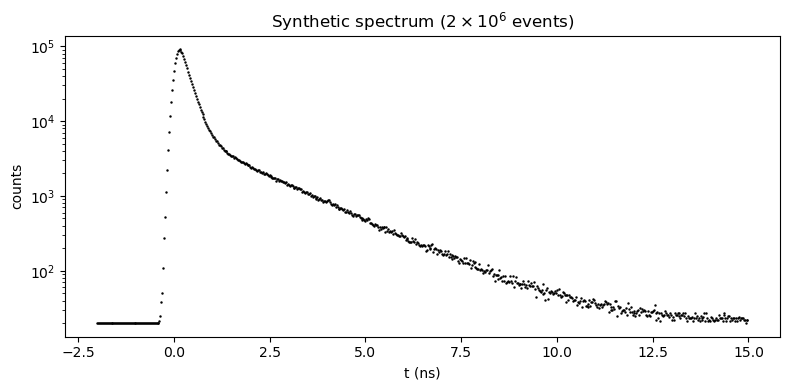

In [2]:
time = np.arange(-2, 15, 0.025)                     # ns
irf_sigma = np.array([0.230 / (2 * np.sqrt(2 * np.log(2)))])
irf = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.zeros_like(irf_sigma))

true_taus = [0.22, 1.80]
true_I = [0.75, 0.25]
true_t0 = 0.05
bg_true = 20.0

# Inject a genuine time-zero offset by centering the *generating* IRF at true_t0.
# The fit is given the centered `irf`, so its free t0 parameter must absorb the
# shift. (Subtracting true_t0 from the time axis would not do this — it just
# relabels the axis, leaving t0 = 0 on the spectrum's own grid.)
irf_shifted = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.array([true_t0]))
truth_model = LifetimeModel("truth", lifetimes=np.array(true_taus), intensities=true_I)
r = generate_random_lt_spectrum(time, truth_model, irf_shifted, num_events=2_000_000)
pals = PASLifetime(
    lifetime=Spectrum(counts=r.lifetime.counts + bg_true, axis_calib=r.lifetime.axis_calib),
    resolution=irf,
)

plt.figure(figsize=(8, 4))
plt.semilogy(time, pals.lifetime.counts, 'k.', ms=1.5)
plt.xlabel('t (ns)'); plt.ylabel('counts')
plt.title('Synthetic spectrum ($2\\times 10^6$ events)')
plt.tight_layout()

## 2. Fit with all parameters free

Initial guesses deliberately off; $t_0$ and background are free as well.

In [3]:
fitter = LifetimeFitter()
result = fitter.fit(
    pals,
    lifetimes=[FitParameter(0.3), FitParameter(1.2)],
    intensities=[FitParameter(0.5), FitParameter(0.5)],
    t0=FitParameter(0.0),
    background=FitParameter(10.0, lower=0.0),
)

print(f"success: {result.success},  reduced chi2 = {result.reduced_chi_squared:.3f}")
print(f"{'param':<8}{'fitted':>10}{'error':>10}{'truth':>10}")
err = result.parameter_errors
for i, (tau, I) in enumerate(zip(result.model.lifetimes, result.model.intensities)):
    print(f"tau_{i:<4}{tau:>10.4f}{err.get(f'tau_{i}', 0):>10.4f}{true_taus[i]:>10.4f}")
    print(f"I_{i:<6}{I:>10.4f}{err.get(f'I_{i}', float('nan')):>10.4f}{true_I[i]:>10.4f}")
print(f"{'t0':<8}{result.t0:>10.4f}{err['t0']:>10.4f}{true_t0:>10.4f}")
print(f"{'bg':<8}{result.background:>10.4f}{err['bg']:>10.4f}{bg_true:>10.4f}")

success: True,  reduced chi2 = 0.579
param       fitted     error     truth
tau_0       0.2197    0.0003    0.2200
I_0         0.7495    0.0004    0.7500
tau_1       1.8008    0.0034    1.8000
I_1         0.2505       nan    0.2500
t0          0.0502    0.0002    0.0500
bg         19.8214    0.2465   20.0000


Note `I_1` has no quoted error: it is the dependent intensity ($1 - I_0$), so its uncertainty equals that of $I_0$.

## 3. Fit quality: spectrum and weighted residuals

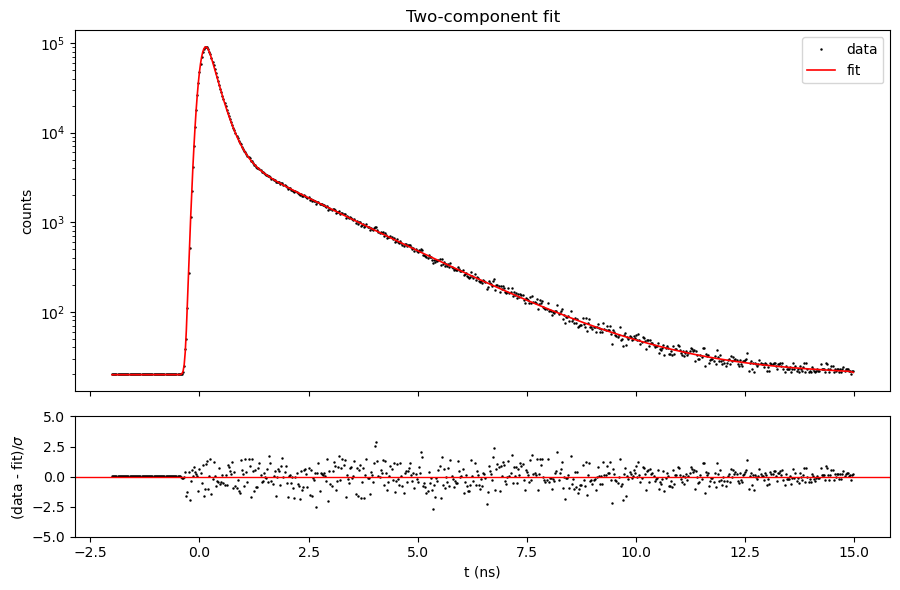

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
axes[0].semilogy(time, pals.lifetime.counts, 'k.', ms=1.5, label='data')
axes[0].semilogy(time, result.fitted_spectrum, 'r-', lw=1.2, label='fit')
axes[0].set_ylabel('counts'); axes[0].legend()
axes[0].set_title('Two-component fit')

axes[1].plot(time, result.residuals, 'k.', ms=1.5)
axes[1].axhline(0, color='r', lw=1)
axes[1].set_xlabel('t (ns)'); axes[1].set_ylabel(r'(data - fit)/$\sigma$')
axes[1].set_ylim(-5, 5)
plt.tight_layout()

Structureless residuals at the $\pm\sigma$ level confirm the model describes the data.

## 4. Source correction via fixed parameters

In real measurements a fraction of positrons annihilate in the source (e.g. ~10% in the Kapton envelope, $\tau \approx 0.382$ ns). Generate a spectrum that includes this component, then fit with the source $\tau$ and $I$ **fixed** to their known values — only the sample components are free.

In [5]:
src_tau, src_I = 0.382, 0.10
taus_3 = [0.22, 1.80, src_tau]
I_3 = [0.675, 0.225, src_I]          # sample intensities scaled by (1 - src_I)

model_3 = LifetimeModel("with-source", lifetimes=np.array(taus_3), intensities=I_3)
r3 = generate_random_lt_spectrum(time, model_3, irf_shifted, num_events=2_000_000)
pals_3 = PASLifetime(
    lifetime=Spectrum(counts=r3.lifetime.counts + bg_true, axis_calib=r3.lifetime.axis_calib),
    resolution=irf,
)

result_src = fitter.fit(
    pals_3,
    lifetimes=[FitParameter(0.3), FitParameter(1.2),
               FitParameter(src_tau, fixed=True)],
    intensities=[FitParameter(0.5), FitParameter(0.4),
                 FitParameter(src_I, fixed=True)],
    t0=FitParameter(0.0),
    background=FitParameter(10.0, lower=0.0),
)

print(f"success: {result_src.success},  reduced chi2 = {result_src.reduced_chi_squared:.3f}")
err = result_src.parameter_errors
for i in range(2):
    tau = result_src.model.lifetimes[i]
    I = result_src.model.intensities[i]
    print(f"tau_{i} = {tau:.4f} ± {err.get(f'tau_{i}', 0):.4f}   (truth {taus_3[i]})")
    print(f"I_{i}   = {I:.4f}            (truth {I_3[i]})")
print(f"source component held at tau = {result_src.model.lifetimes[2]}, "
      f"I = {result_src.model.intensities[2]:.3f}")

success: True,  reduced chi2 = 0.653
tau_0 = 0.2203 ± 0.0004   (truth 0.22)
I_0   = 0.6754            (truth 0.675)
tau_1 = 1.7977 ± 0.0039   (truth 1.8)
I_1   = 0.2246            (truth 0.225)
source component held at tau = 0.382, I = 0.100


The sample lifetimes are recovered correctly while the source component stays clamped at its calibrated values.

## 5. Bounded parameters

Bounds keep the optimizer in the physical region — useful when components are close or statistics are poor. For example, constraining the second lifetime to the range expected for a defect:

In [6]:
result_b = fitter.fit(
    pals,
    lifetimes=[FitParameter(0.3, lower=0.05, upper=0.6),
               FitParameter(1.2, lower=1.0, upper=3.0)],
    intensities=[FitParameter(0.5), FitParameter(0.5)],
    t0=FitParameter(0.0),
    background=FitParameter(10.0, lower=0.0),
)
print(f"tau = {result_b.model.lifetimes.round(4)},  I = {result_b.model.intensities.round(4)}")
print(f"reduced chi2 = {result_b.reduced_chi_squared:.3f}")

tau = [0.2197 1.8008],  I = [0.7495 0.2505]
reduced chi2 = 0.579
